### 데이터셋

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mglearn
import warnings
warnings.filterwarnings('ignore')

x.shape: (26, 2)


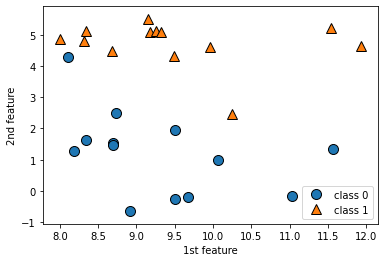

In [8]:
# 데이터셋을 만듭니다.
x, y = mglearn.datasets.make_forge()
# 산점도를 그립니다.
mglearn.discrete_scatter(x[:,0],x[:,1],y)
plt.legend(['class 0','class 1'], loc=4)
plt.xlabel('1st feature')
plt.ylabel('2nd feature')
print('x.shape:', x.shape)

Text(0, 0.5, 'target')

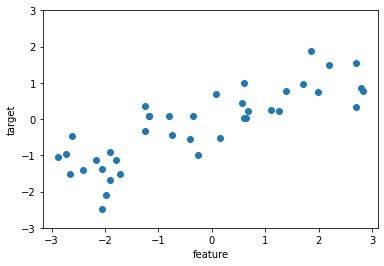

In [9]:
x, y = mglearn.datasets.make_wave(n_samples=40)
plt.plot(x,y,'o')
plt.ylim(-3,3)
plt.xlabel('feature')
plt.ylabel('target')

In [10]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print('cancer.keys():\n', cancer.keys())

cancer.keys():
 dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [12]:
print('cancer shape:', cancer.data.shape)

cancer shape: (569, 30)


In [13]:
print('sample number per class:\n', {n: v for n, v in zip(cancer.target_names, np.bincount(cancer.target))})

sample number per class:
 {'malignant': 212, 'benign': 357}


In [14]:
print('feature names:\n', cancer.feature_names)

feature names:
 ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [15]:
from sklearn.datasets import load_boston
boston = load_boston()
print('data shape:', boston.data.shape)

data shape: (506, 13)


In [16]:
x, y = mglearn.datasets.load_extended_boston()
print('x.shape:', x.shape)

x.shape: (506, 104)


### k-최근접 이웃 - 분류

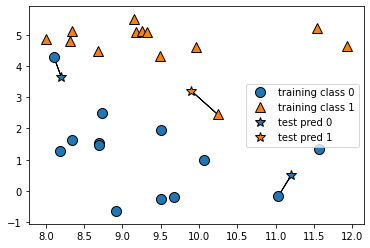

In [17]:
mglearn.plots.plot_knn_classification(n_neighbors=1)

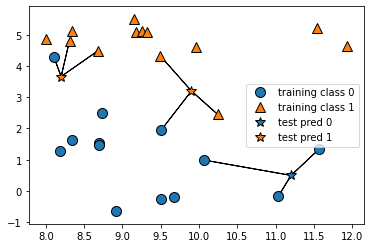

In [18]:
mglearn.plots.plot_knn_classification(n_neighbors=3)

In [19]:
from sklearn.model_selection import train_test_split
x, y = mglearn.datasets.make_forge()

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

In [20]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=3)

In [21]:
clf.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [22]:
print('test set predict:', clf.predict(x_test))

test set predict: [1 0 1 0 1 0 0]


In [23]:
print('test set accuracy: {:.2f}'.format(clf.score(x_test, y_test)))

test set accuracy: 0.86


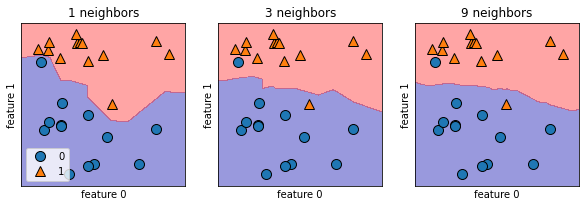

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(10,3))

for n_neighbors, ax in zip([1,3,9], axes):
    # fit 메소드는 self 오브젝트를 리턴합니다
    # 그래서 객체 생성과 fit 메소드를 한 줄에 쓸 수 있습니다
    clf = KNeighborsClassifier(n_neighbors=n_neighbors).fit(x, y)
    mglearn.plots.plot_2d_separator(clf, x, fill=True, eps=0.5, ax=ax, alpha=.4)
    mglearn.discrete_scatter(x[:,0], x[:,1], y, ax=ax)
    ax.set_title('{} neighbors'.format(n_neighbors))
    ax.set_xlabel('feature 0')
    ax.set_ylabel('feature 1')
axes[0].legend(loc=3)

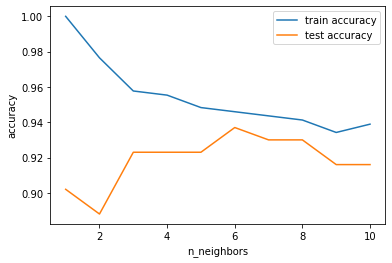

In [25]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
x_train, x_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=66)

training_accuracy = []
test_accuracy = []
# 1에서 10까지 n_neighbors 를 적용
neighbors_settings = range(1,11)
for n_neighbors in neighbors_settings:
    # 모델 생성
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(x_train, y_train)
    # 훈련 세트 정확도 저장
    training_accuracy.append(clf.score(x_train, y_train))
    # 일반화 정확도 저장
    test_accuracy.append(clf.score(x_test, y_test))
    
plt.plot(neighbors_settings, training_accuracy, label='train accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()

### k-최근접 이웃 - 회귀

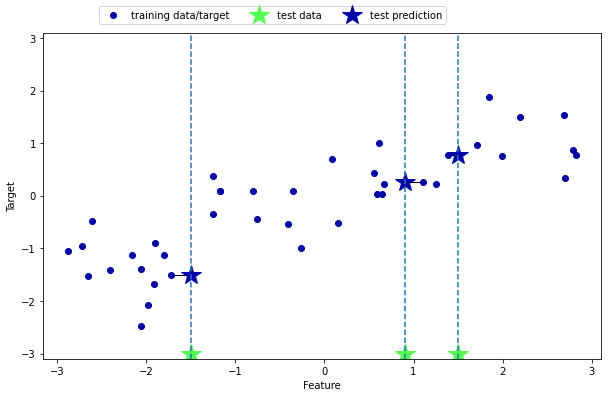

In [26]:
mglearn.plots.plot_knn_regression(n_neighbors=1)

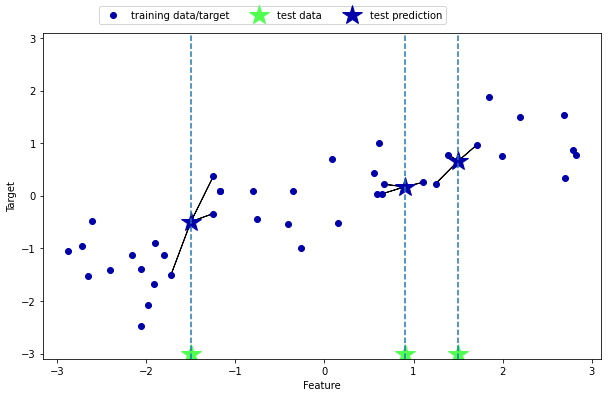

In [27]:
mglearn.plots.plot_knn_regression(n_neighbors=3)

In [28]:
from sklearn.neighbors import KNeighborsRegressor

x, y = mglearn.datasets.make_wave(n_samples=40)

# wave 데이터셋을 훈련 세트와 데스트 세트로 나눕니다
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

# 이웃의 수를 3으로 하여 모델의 객체를 만듭니다
reg = KNeighborsRegressor(n_neighbors=3)
# 훈련 데이터와 타깃을 사용하여 모델을 학습시킵니다
reg.fit(x_train, y_train)

KNeighborsRegressor(n_neighbors=3)

In [29]:
print('test set predict:\n', reg.predict(x_test))

test set predict:
 [-0.05396539  0.35686046  1.13671923 -1.89415682 -1.13881398 -1.63113382
  0.35686046  0.91241374 -0.44680446 -1.13881398]


In [30]:
print('test set R^2: {:.2f}'.format(reg.score(x_test, y_test)))

test set R^2: 0.83


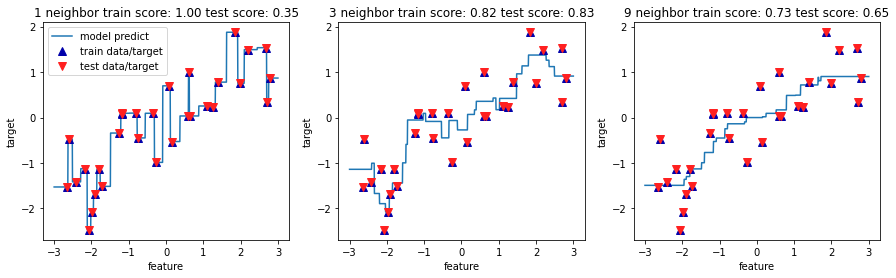

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
# -3 과 3 사이에 1,000개의 데이터 포인트를 만듭니다
line = np.linspace(-3,3,1000).reshape(-1,1)
for n_neighbors, ax in zip([1,3,9], axes):
    # 1,3,9 이웃을 사용한 예측을 합니다
    reg = KNeighborsRegressor(n_neighbors=n_neighbors)
    reg.fit(x_train, y_train)
    ax.plot(line, reg.predict(line))
    ax.plot(x_train, y_train, '^', c=mglearn.cm2(0), markersize=8)
    ax.plot(x_train, y_train, 'v', c=mglearn.cm2(1), markersize=8)
    
    ax.set_title('{} neighbor train score: {:.2f} test score: {:.2f}'.format(n_neighbors, 
                                                                             reg.score(x_train, y_train), reg.score(x_test, y_test)))
    ax.set_xlabel('feature')
    ax.set_ylabel('target')
axes[0].legend(['model predict', 'train data/target', 'test data/target'], loc='best')

### 선형모델

w[0]: 0.393906  b: -0.031804


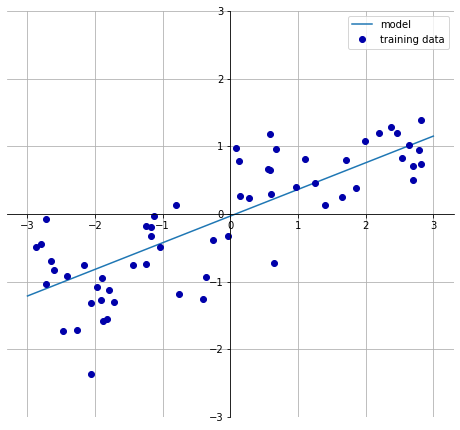

In [2]:
mglearn.plots.plot_linear_regression_wave()

### 선형 회귀(최소제곱법)

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
x, y = mglearn.datasets.make_wave(n_samples=60)
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)

lr = LinearRegression().fit(x_train, y_train)

In [4]:
print('lr.coef_:', lr.coef_) # 계수
print('lr.intercept_:', lr.intercept_) # 절편

lr.coef_: [0.39390555]
lr.intercept_: -0.03180434302675973


In [5]:
print('train set score: {:.2f}'.format(lr.score(x_train, y_train)))
print('test set score: {:.2f}'.format(lr.score(x_test, y_test)))

train set score: 0.67
test set score: 0.66


In [6]:
x, y = mglearn.datasets.load_extended_boston()

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)
lr = LinearRegression().fit(x_train, y_train)

In [7]:
print('train set score: {:.2f}'.format(lr.score(x_train, y_train)))
print('test set score: {:.2f}'.format(lr.score(x_test, y_test)))

train set score: 0.95
test set score: 0.61


### 릿지 회귀

In [9]:
from sklearn.linear_model import Ridge

ridge = Ridge().fit(x_train, y_train)
print('train set score: {:.2f}'.format(ridge.score(x_train, y_train)))
print('test set score: {:.2f}'.format(ridge.score(x_test, y_test)))

train set score: 0.89
test set score: 0.75


In [11]:
ridge10 = Ridge(alpha=10).fit(x_train, y_train)
print('train set score: {:.2f}'.format(ridge10.score(x_train, y_train)))
print('test set score: {:.2f}'.format(ridge10.score(x_test, y_test)))

train set score: 0.79
test set score: 0.64


In [12]:
ridge01 = Ridge(alpha=0.1).fit(x_train, y_train)
print('train set score: {:.2f}'.format(ridge01.score(x_train, y_train)))
print('test set score: {:.2f}'.format(ridge01.score(x_test, y_test)))

train set score: 0.93
test set score: 0.77


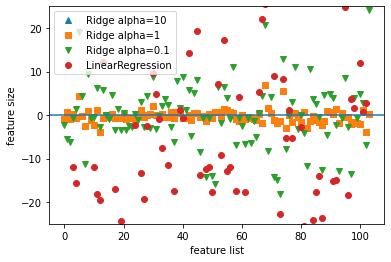

In [13]:
plt.plot(ridge10.coef_, '^', label='Ridge alpha=10')
plt.plot(ridge.coef_, 's', label='Ridge alpha=1')
plt.plot(ridge01.coef_, 'v', label='Ridge alpha=0.1')

plt.plot(lr.coef_, 'o', label='LinearRegression')
plt.xlabel('feature list')
plt.ylabel('feature size')
xlims = plt.xlim()
plt.hlines(0, xlims[0], xlims[1])
plt.xlim(xlims)
plt.ylim(-25,25)
plt.legend()

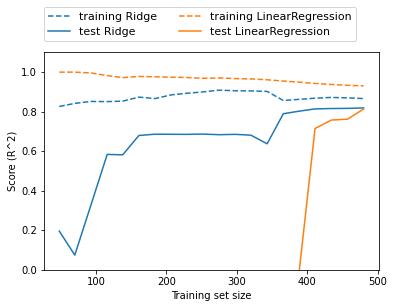

In [14]:
mglearn.plots.plot_ridge_n_samples()

### 라쏘 회귀

In [15]:
from sklearn.linear_model import Lasso

lasso = Lasso().fit(x_train, y_train)
print('train set score: {:.2f}'.format(lasso.score(x_train, y_train)))
print('test set score: {:.2f}'.format(lasso.score(x_test, y_test)))
print("used features number:", np.sum(lasso.coef_ != 0))

train set score: 0.29
test set score: 0.21
used features number: 4


In [16]:
# max_iter 기본값을 증가시키지 않으면 max_iter 값을 늘리라는 경고가 발생합니다
lasso001 = Lasso(alpha=0.01, max_iter=50000).fit(x_train, y_train)
print('train set score: {:.2f}'.format(lasso001.score(x_train, y_train)))
print('test set score: {:.2f}'.format(lasso001.score(x_test, y_test)))
print("used features number:", np.sum(lasso001.coef_ != 0))

train set score: 0.90
test set score: 0.77
used features number: 33


In [17]:
lasso00001 = Lasso(alpha=0.0001, max_iter=50000).fit(x_train, y_train)
print('train set score: {:.2f}'.format(lasso00001.score(x_train, y_train)))
print('test set score: {:.2f}'.format(lasso00001.score(x_test, y_test)))
print("used features number:", np.sum(lasso00001.coef_ != 0))

train set score: 0.95
test set score: 0.64
used features number: 96


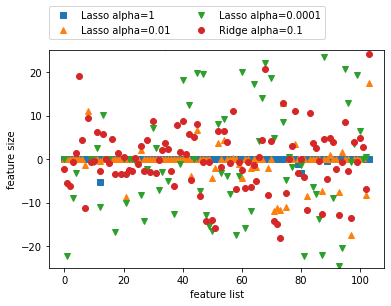

In [18]:
plt.plot(lasso.coef_, 's', label='Lasso alpha=1')
plt.plot(lasso001.coef_, '^', label='Lasso alpha=0.01')
plt.plot(lasso00001.coef_, 'v', label='Lasso alpha=0.0001')

plt.plot(ridge01.coef_, 'o', label='Ridge alpha=0.1')
plt.xlabel('feature list')
plt.ylabel('feature size')
plt.ylim(-25,25)
plt.legend(ncol=2, loc=(0,1.05))

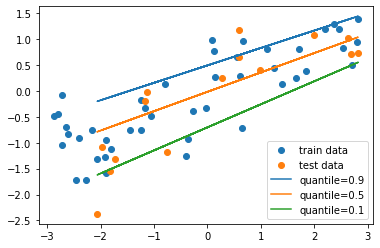

In [19]:
from sklearn.linear_model import QuantileRegressor

x, y = mglearn.datasets.make_wave(n_samples=60)
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42)

pred_up = QuantileRegressor(quantile=0.9, alpha=0.01).fit(x_train, y_train).predict(x_test)
pred_med = QuantileRegressor(quantile=0.5, alpha=0.01).fit(x_train, y_train).predict(x_test)
pred_low = QuantileRegressor(quantile=0.1, alpha=0.01).fit(x_train, y_train).predict(x_test)

plt.scatter(x_train, y_train, label='train data')
plt.scatter(x_test, y_test, label='test data')
plt.plot(x_test, pred_up, label='quantile=0.9')
plt.plot(x_test, pred_med, label='quantile=0.5')
plt.plot(x_test, pred_low, label='quantile=0.1')
plt.legend()
plt.show()

### 이진 클래스 분류용 선형 모델

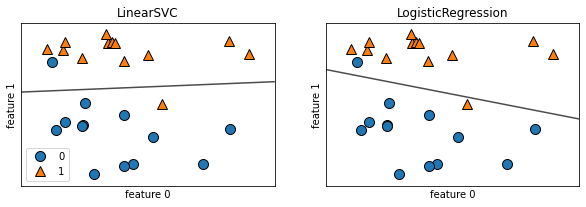

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

x, y = mglearn.datasets.make_forge()

fig, axes = plt.subplots(1, 2, figsize=(10,3))

for model, ax in zip([LinearSVC(max_iter=5000), LogisticRegression()], axes):
    clf = model.fit(x, y)
    mglearn.plots.plot_2d_separator(clf, x, fill=False, eps=0.5, ax=ax, alpha=.7)
    mglearn.discrete_scatter(x[:,0], x[:,1], y, ax=ax)
    ax.set_title(clf.__class__.__name__)
    ax.set_xlabel('feature 0')
    ax.set_ylabel('feature 1')
axes[0].legend()

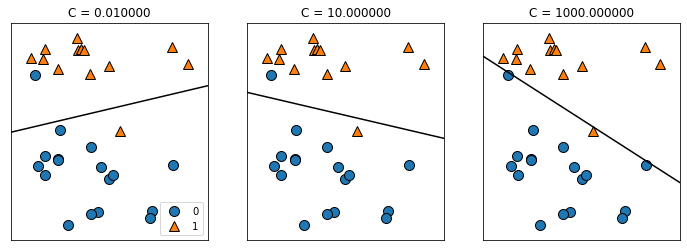

In [21]:
mglearn.plots.plot_linear_svc_regularization()

In [22]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
x_train, x_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=42)
logreg = LogisticRegression(max_iter=5000).fit(x_train, y_train)
print('train test score: {:.3f}'.format(logreg.score(x_train, y_train)))
print('test set score: {:.3f}'.format(logreg.score(x_test, y_test)))

train test score: 0.958
test set score: 0.958


In [23]:
logreg100 = LogisticRegression(C=100, max_iter=5000).fit(x_train, y_train)
print('train test score: {:.3f}'.format(logreg100.score(x_train, y_train)))
print('test set score: {:.3f}'.format(logreg100.score(x_test, y_test)))

train test score: 0.984
test set score: 0.965


In [24]:
logreg001 = LogisticRegression(C=0.01, max_iter=5000).fit(x_train, y_train)
print('train test score: {:.3f}'.format(logreg001.score(x_train, y_train)))
print('test set score: {:.3f}'.format(logreg001.score(x_test, y_test)))

train test score: 0.953
test set score: 0.951


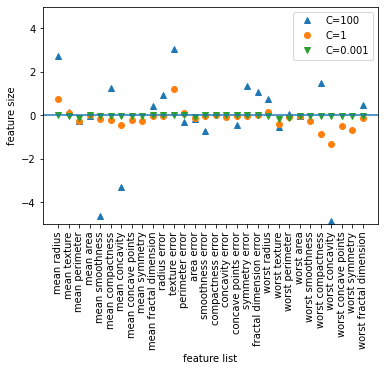

In [25]:
plt.plot(logreg100.coef_.T, '^', label='C=100')
plt.plot(logreg.coef_.T, 'o', label='C=1')
plt.plot(logreg001.coef_.T, 'v', label='C=0.001')
plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)

plt.xlabel('feature list')
plt.ylabel('feature size')
xlims = plt.xlim()
plt.hlines(0, xlims[0], xlims[1])
plt.xlim(xlims)
plt.ylim(-5,5)
plt.legend()

C=0.001 인 l1 로지스틱 회귀의 훈련 정확도: 0.91
C=0.001 인 l1 로지스틱 회귀의 테스트 정확도: 0.92
C=1.000 인 l1 로지스틱 회귀의 훈련 정확도: 0.96
C=1.000 인 l1 로지스틱 회귀의 테스트 정확도: 0.96
C=100.000 인 l1 로지스틱 회귀의 훈련 정확도: 0.99
C=100.000 인 l1 로지스틱 회귀의 테스트 정확도: 0.98


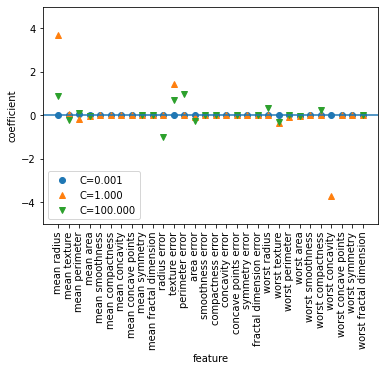

In [26]:
for c, marker in zip([0.001, 1, 100], ['o','^','v']):
    lr_l1 = LogisticRegression(solver='liblinear', C=c, penalty='l1', max_iter=1000).fit(x_train, y_train)
    print('C={:.3f} 인 l1 로지스틱 회귀의 훈련 정확도: {:.2f}'.format(c, lr_l1.score(x_train, y_train)))
    print('C={:.3f} 인 l1 로지스틱 회귀의 테스트 정확도: {:.2f}'.format(c, lr_l1.score(x_test, y_test)))
    plt.plot(lr_l1.coef_.T, marker, label='C={:.3f}'.format(c))

plt.xticks(range(cancer.data.shape[1]), cancer.feature_names, rotation=90)
xlims = plt.xlim()
plt.hlines(0, xlims[0], xlims[1])
plt.xlim(xlims)
plt.xlabel('feature')
plt.ylabel('coefficient')
plt.ylim(-5,5)
plt.legend(loc=3)

### 다중 클래스 분류용 선형 모델

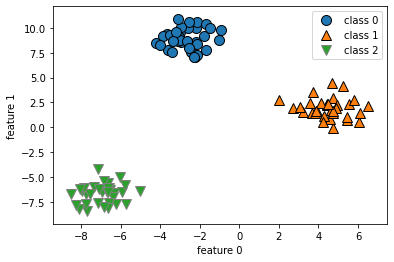

In [27]:
from sklearn.datasets import make_blobs

x, y = make_blobs(random_state=42)
mglearn.discrete_scatter(x[:,0], x[:,1], y)
plt.xlabel('feature 0')
plt.ylabel('feature 1')
plt.legend(['class 0','class 1','class 2'])

In [28]:
linear_svm = LinearSVC().fit(x,y)
print('coef.shape:', linear_svm.coef_.shape)
print('intecept.shape:', linear_svm.intercept_.shape)

coef.shape: (3, 2)
intecept.shape: (3,)


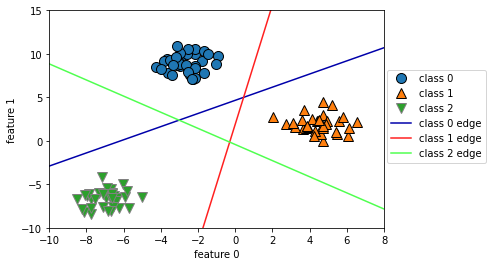

In [31]:
mglearn.discrete_scatter(x[:,0], x[:,1], y)
line = np.linspace(-15,15)
for coef, intercept, color in zip(linear_svm.coef_, linear_svm.intercept_, mglearn.cm3.colors):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)
plt.ylim(-10,15)
plt.xlim(-10,8)
plt.xlabel('feature 0')
plt.ylabel('feature 1')
plt.legend(['class 0','class 1','class 2','class 0 edge','class 1 edge','class 2 edge'], loc=(1.01,0.3))

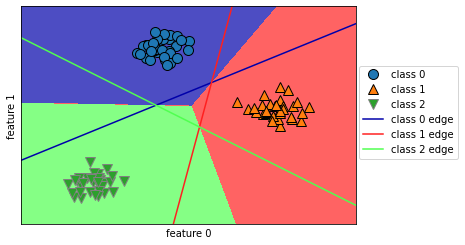

In [32]:
mglearn.plots.plot_2d_classification(linear_svm, x, fill=True, alpha=.7)
mglearn.discrete_scatter(x[:,0], x[:,1], y)
line = np.linspace(-15,15)
for coef, intercept, color in zip(linear_svm.coef_, linear_svm.intercept_, mglearn.cm3.colors):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)
plt.xlabel('feature 0')
plt.ylabel('feature 1')
plt.legend(['class 0','class 1','class 2','class 0 edge','class 1 edge','class 2 edge'], loc=(1.01,0.3))

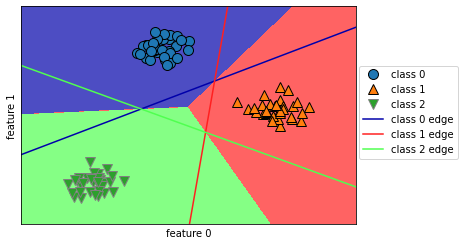

In [33]:
from sklearn.linear_model import SGDClassifier

sgd_c = SGDClassifier(alpha=0.01, learning_rate='adaptive', eta0=0.1, random_state=42, n_jobs=-1)
sgd_c.fit(x,y)

mglearn.plots.plot_2d_classification(sgd_c, x, fill=True, alpha=.7)
mglearn.discrete_scatter(x[:,0],x[:,1],y)
line = np.linspace(-15,15)
for coef, intercept, color in zip(sgd_c.coef_, sgd_c.intercept_, mglearn.cm3.colors):
    plt.plot(line, -(line * coef[0] + intercept) / coef[1], c=color)
plt.xlabel('feature 0')
plt.ylabel('feature 1')
plt.legend(['class 0','class 1','class 2','class 0 edge','class 1 edge','class 2 edge'], loc=(1.01,0.3))
plt.show()

In [34]:
from sklearn.linear_model import SGDRegressor

x, y = mglearn.datasets.load_extended_boston()
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=0)

sgd_r = SGDRegressor(learning_rate='adaptive', eta0=0.1, random_state=42)
sgd_r.fit(x_train, y_train)

print('train set score: {:.2f}'.format(sgd_r.score(x_train, y_train)))
print('test set score: {:.2f}'.format(sgd_r.score(x_test, y_test)))

train set score: 0.91
test set score: 0.77


### 나이브 베이즈 분류기

In [35]:
x = np.array([[0,1,0,1],
              [1,0,1,1],
              [0,0,0,1],
              [1,0,1,0]])
y = np.array([0,1,0,1])

In [36]:
counts = {}
for label in np.unique(y):
    # 각 클래스에 대해 반복
    # 특성마다 1 이 나타난 횟수를 센다
    counts[label] = x[y == label].sum(axis=0)
print('feature count:\n', counts)

feature count:
 {0: array([0, 1, 0, 2]), 1: array([2, 0, 2, 1])}


### 결정 트리

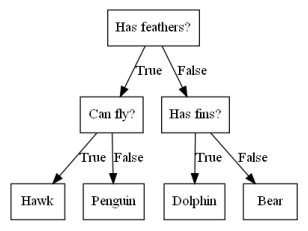

In [40]:
mglearn.plots.plot_animal_tree()

In [41]:
from sklearn.tree import DecisionTreeClassifier

cancer = load_breast_cancer()
x_train, x_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify=cancer.target, random_state=42)
tree = DecisionTreeClassifier(random_state=0)
tree.fit(x_train, y_train)
print('train set score: {:.3f}'.format(tree.score(x_train, y_train)))
print('test set score: {:.3f}'.format(tree.score(x_test, y_test)))

train set score: 1.000
test set score: 0.937


In [42]:
tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(x_train, y_train)

print('train set score: {:.3f}'.format(tree.score(x_train, y_train)))
print('test set score: {:.3f}'.format(tree.score(x_test, y_test)))

train set score: 0.988
test set score: 0.951


In [45]:
from sklearn.tree import export_graphviz
export_graphviz(tree, out_file='tree.dot', class_names=['bad','good'], 
                feature_names=cancer.feature_names, impurity=False, filled=True)

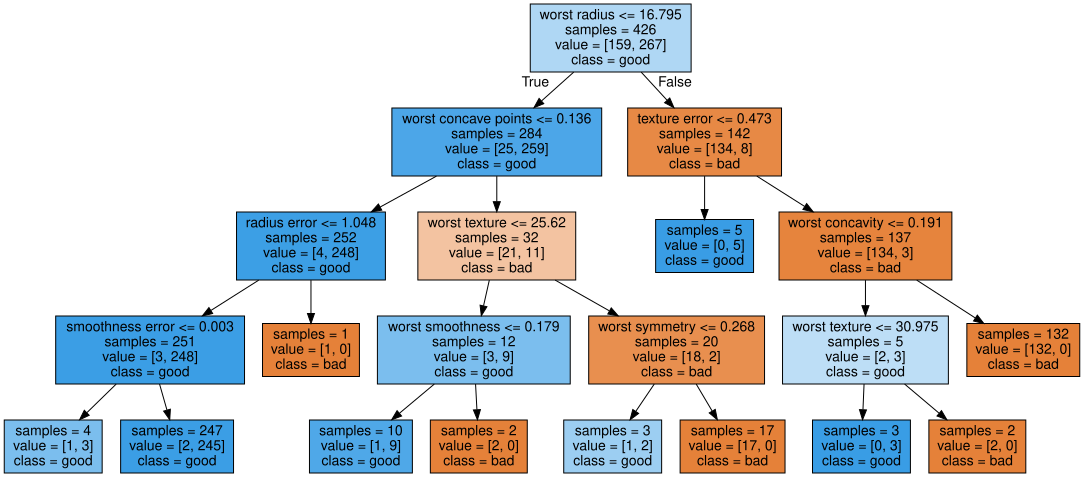

In [46]:
import graphviz

with open('tree.dot') as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

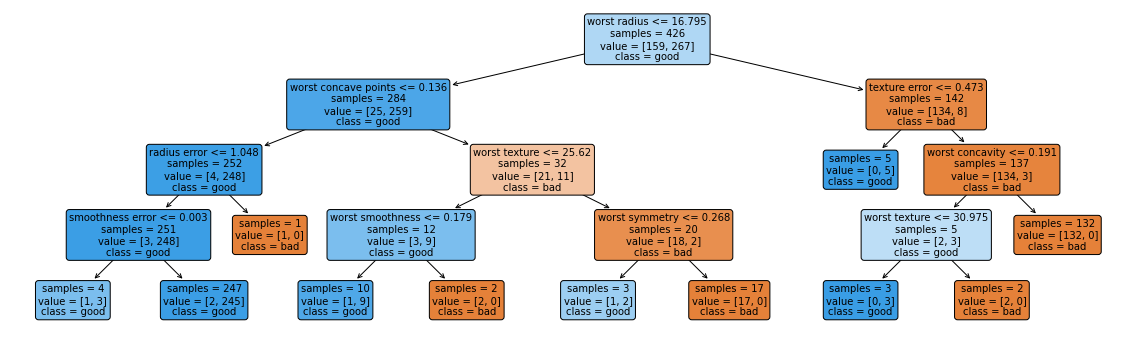

In [48]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,6))
plot_tree(tree, class_names=['bad','good'], feature_names=cancer.feature_names,
          impurity=False, filled=True, rounded=True, fontsize=10)
plt.show()

In [49]:
print('feature importance:\n', tree.feature_importances_)

feature importance:
 [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.01019737 0.04839825
 0.         0.         0.0024156  0.         0.         0.
 0.         0.         0.72682851 0.0458159  0.         0.
 0.0141577  0.         0.018188   0.1221132  0.01188548 0.        ]


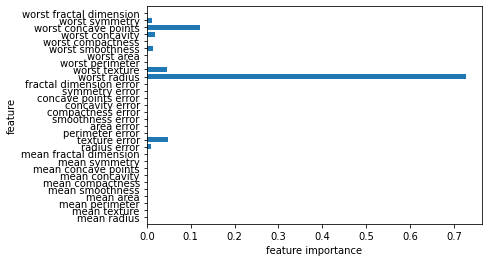

In [50]:
def plot_feature_importances_cancer(model):
    n_features = cancer.data.shape[1]
    plt.barh(np.arange(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), cancer.feature_names)
    plt.xlabel('feature importance')
    plt.ylabel('feature')
    plt.ylim(-1, n_features)

plot_feature_importances_cancer(tree)

Feature importances: [0. 1.]


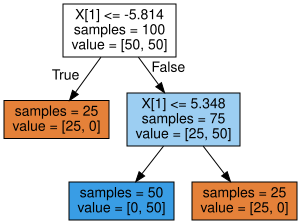

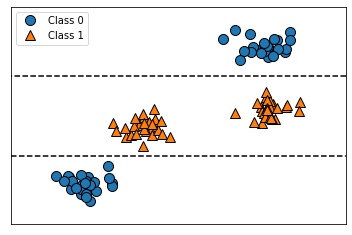

In [51]:
mglearn.plots.plot_tree_not_monotone()

Text(0, 0.5, 'prcie (%/Mbyte)')

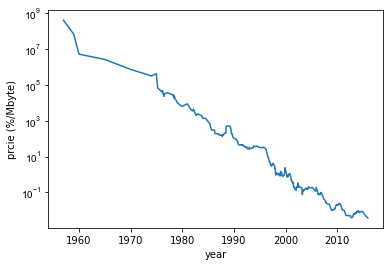

In [52]:
import os
ram_prices = pd.read_csv(os.path.join(mglearn.datasets.DATA_PATH, 'ram_price.csv'))

plt.yticks(fontname='Arial')
plt.semilogy(ram_prices.date, ram_prices.price)
plt.xlabel('year')
plt.ylabel('prcie (%/Mbyte)')

In [53]:
from sklearn.tree import DecisionTreeRegressor
# 2000년 이전을 훈련 데이터로, 2000년 이후를 테스트 데이터로 만듭니다
data_train = ram_prices[ram_prices.date < 2000]
data_test = ram_prices[ram_prices.date >= 2000]

# 가격 예측을 위해 날짜 특성만을 이용합니다
x_train = data_train.date.to_numpy()[:, np.newaxis]
# 데이터와 타깃 사이의 관계를 간단하게 만들기 위해 로그 스케일로 바꿉니다
y_train = np.log(data_train.price)

tree = DecisionTreeRegressor().fit(x_train, y_train)
linear_reg = LinearRegression().fit(x_train, y_train)

# 예측은 전체 기간에 대해서 수행합니다
x_all = ram_prices.date.to_numpy()[:, np.newaxis]

pred_tree = tree.predict(x_all)
pred_lr = linear_reg.predict(x_all)

# 예측한 값의 로그 스케일을 되돌립니다
price_tree = np.exp(pred_tree)
price_lr = np.exp(pred_lr)

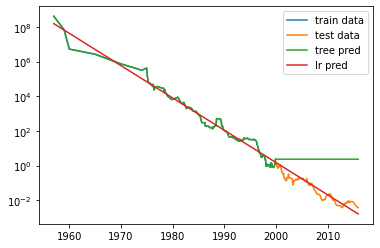

In [54]:
plt.semilogy(data_train.date, data_train.price, label='train data')
plt.semilogy(data_test.date, data_test.price, label='test data')
plt.semilogy(ram_prices.date, price_tree, label='tree pred')
plt.semilogy(ram_prices.date, price_lr, label='lr pred')
plt.legend()

In [56]:
tree.fit(data_train[['date']], y_train)

print('feature number:', tree.n_features_in_)
print('feature name:', tree.feature_names_in_)

feature number: 1
feature name: ['date']


### 랜덤 포레스트

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons

x, y = make_moons(n_samples=100, noise=0.25, random_state=3)
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, random_state=42)

forest = RandomForestClassifier(n_estimators=5, random_state=2)
forest.fit(x_train, y_train)

RandomForestClassifier(n_estimators=5, random_state=2)

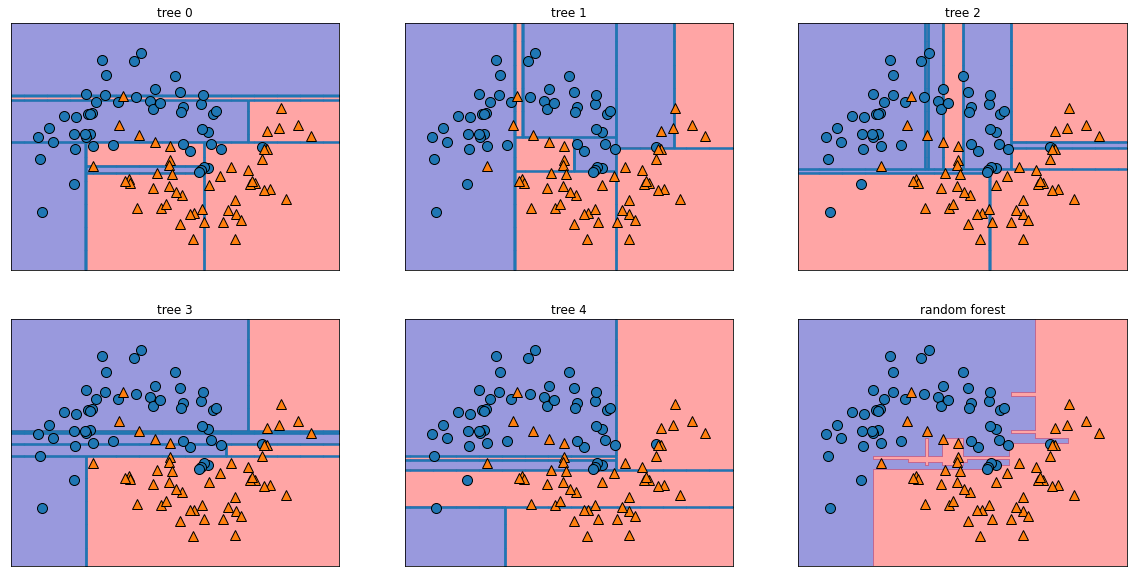

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(20,10))
for i, (ax, tree) in enumerate(zip(axes.ravel(), forest.estimators_)):
    ax.set_title('tree {}'.format(i))
    mglearn.plots.plot_tree_partition(x, y, tree, ax=ax)
    
mglearn.plots.plot_2d_separator(forest, x, fill=True, ax=axes[-1,-1], alpha=.4)
axes[-1,-1].set_title('random forest')
mglearn.discrete_scatter(x[:,0], x[:,1], y)

In [59]:
x_train, x_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
forest = RandomForestClassifier(n_estimators=100, random_state=0)
forest.fit(x_train, y_train)

print('train set score: {:.3f}'.format(forest.score(x_train, y_train)))
print('test set score: {:.3f}'.format(forest.score(x_test, y_test)))

train set score: 1.000
test set score: 0.972


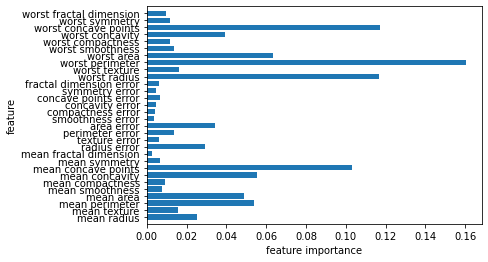

In [60]:
plot_feature_importances_cancer(forest)

### 그래디언트 부스팅 회귀 트리

In [62]:
from sklearn.ensemble import GradientBoostingClassifier

x_train, x_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(x_train, y_train)

print('train set score: {:.3f}'.format(gbrt.score(x_train, y_train)))
print('test set score: {:.3f}'.format(gbrt.score(x_test, y_test)))

train set score: 1.000
test set score: 0.965


In [63]:
gbrt = GradientBoostingClassifier(random_state=0, max_depth=1)
gbrt.fit(x_train, y_train)

print('train set score: {:.3f}'.format(gbrt.score(x_train, y_train)))
print('test set score: {:.3f}'.format(gbrt.score(x_test, y_test)))

train set score: 0.991
test set score: 0.972


In [64]:
gbrt = GradientBoostingClassifier(random_state=0, learning_rate=0.01)
gbrt.fit(x_train, y_train)

print('train set score: {:.3f}'.format(gbrt.score(x_train, y_train)))
print('test set score: {:.3f}'.format(gbrt.score(x_test, y_test)))

train set score: 0.988
test set score: 0.965


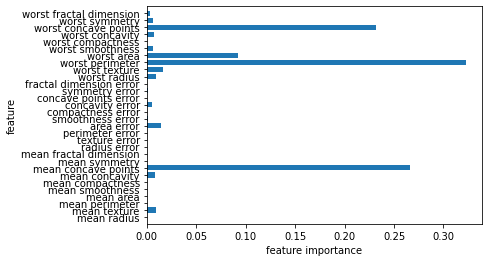

In [65]:
gbrt = GradientBoostingClassifier(random_state=0, max_depth=1)
gbrt.fit(x_train, y_train)

plot_feature_importances_cancer(gbrt)

### 배깅

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.datasets import load_breast_cancer

xm, ym = make_moons(n_samples=100, noise=0.25, random_state=3)
xm_train, xm_test, ym_train, ym_test = train_test_split(xm, ym, stratify=ym, random_state=42)

cancer = load_breast_cancer()
xc_train, xc_test, yc_train, yc_test = train_test_split(cancer.data, cancer.target, random_state=0)

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
bagging = BaggingClassifier(LogisticRegression(solver='liblinear'), n_estimators=100, oob_score=True, n_jobs=-1, random_state=42)
bagging.fit(xc_train, yc_train)

BaggingClassifier(base_estimator=LogisticRegression(solver='liblinear'),
                  n_estimators=100, n_jobs=-1, oob_score=True, random_state=42)

In [69]:
print('train set score: {:.3f}'.format(bagging.score(xc_train, yc_train)))
print('test set score: {:.3f}'.format(bagging.score(xc_test, yc_test)))
print('OOB sample score: {:.3f}'.format(bagging.oob_score_))

train set score: 0.962
test set score: 0.958
OOB sample score: 0.948


In [70]:
from sklearn.tree import DecisionTreeClassifier
bagging = BaggingClassifier(DecisionTreeClassifier(), n_estimators=5, n_jobs=-1, random_state=42)
bagging.fit(xm_train, ym_train)

BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=5,
                  n_jobs=-1, random_state=42)

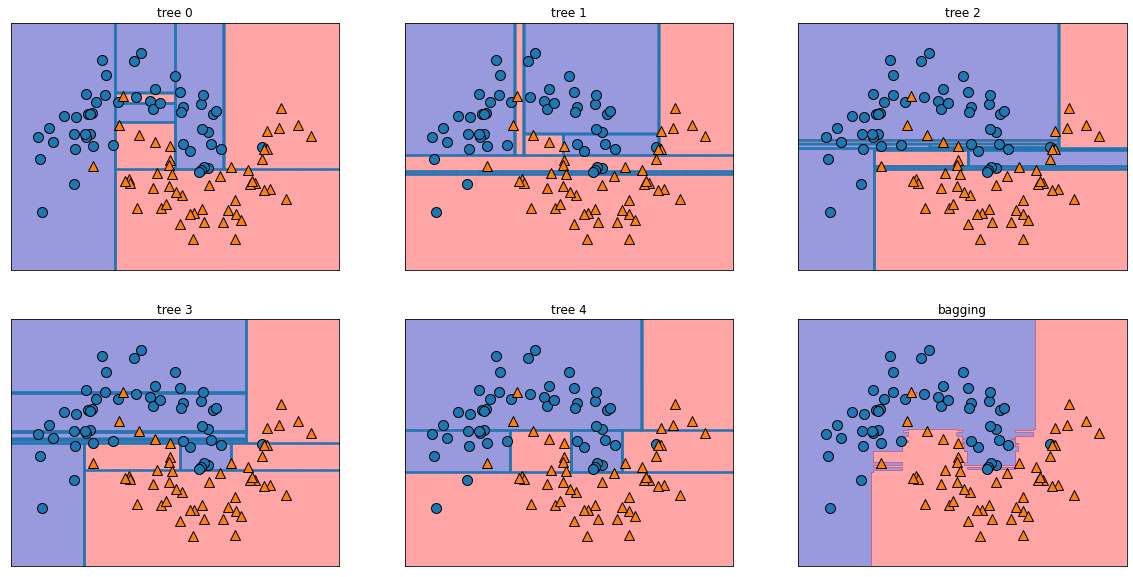

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(20,10))
for i, (ax,tree) in enumerate(zip(axes.ravel(), bagging.estimators_)):
    ax.set_title('tree {}'.format(i))
    mglearn.plots.plot_tree_partition(xm, ym, tree, ax=ax)
    
mglearn.plots.plot_2d_separator(bagging, xm, fill=True, ax=axes[-1,-1], alpha=.4)
axes[-1,-1].set_title('bagging')
mglearn.discrete_scatter(xm[:,0], xm[:,1], ym)
plt.show()

In [72]:
bagging = BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, oob_score=True, n_jobs=-1, random_state=42)
bagging.fit(xc_train, yc_train)

print('train set score: {:.3f}'.format(bagging.score(xc_train, yc_train)))
print('test set score: {:.3f}'.format(bagging.score(xc_test, yc_test)))
print('OOB sample score: {:.3f}'.format(bagging.oob_score_))

train set score: 1.000
test set score: 0.965
OOB sample score: 0.948


### 엑스트라 트리

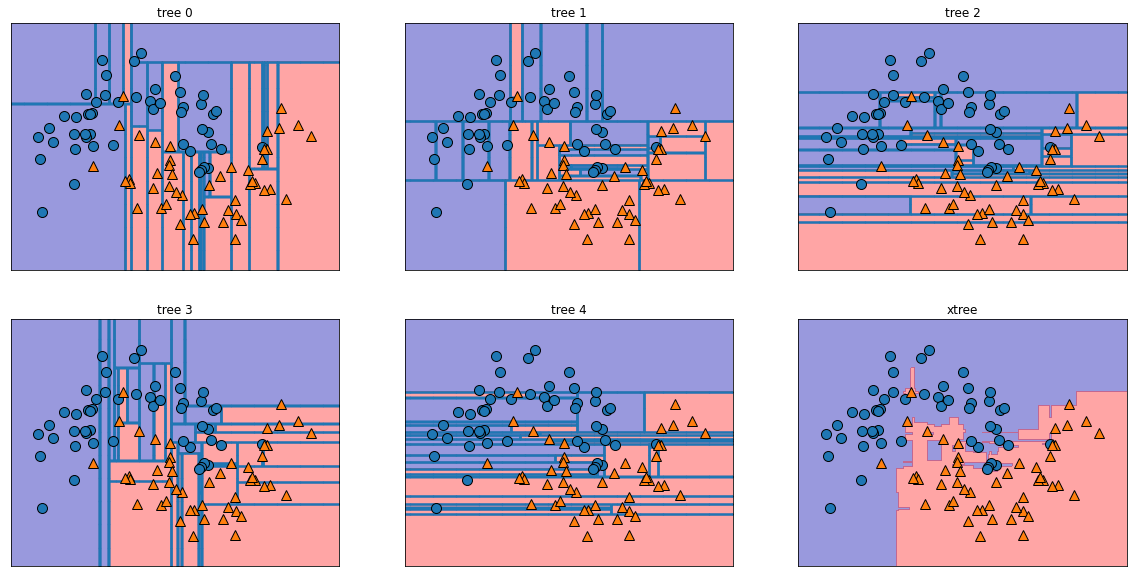

In [73]:
from sklearn.ensemble import ExtraTreesClassifier
xtree = ExtraTreesClassifier(n_estimators=5, n_jobs=-1, random_state=0)
xtree.fit(xm_train, ym_train)

fig, axes = plt.subplots(2, 3, figsize=(20,10))
for i, (ax, tree) in enumerate(zip(axes.ravel(), xtree.estimators_)):
    ax.set_title('tree {}'.format(i))
    mglearn.plots.plot_tree_partition(xm, ym, tree, ax=ax)
    
mglearn.plots.plot_2d_separator(xtree, xm, fill=True, ax=axes[-1,-1], alpha=.4)
axes[-1,-1].set_title('xtree')
mglearn.discrete_scatter(xm[:,0], xm[:,1], ym)
plt.show()

In [74]:
xtree = ExtraTreesClassifier(n_estimators=100, n_jobs=-1, random_state=0)
xtree.fit(xc_train, yc_train)

print('train set score: {:.3f}'.format(xtree.score(xc_train, yc_train)))
print('test set score: {:.3f}'.format(xtree.score(xc_test, yc_test)))

train set score: 1.000
test set score: 0.972


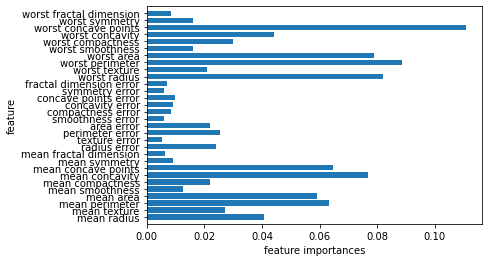

In [75]:
n_features = cancer.data.shape[1]
plt.barh(range(n_features), xtree.feature_importances_, align='center')
plt.yticks(np.arange(n_features), cancer.feature_names)
plt.xlabel('feature importances')
plt.ylabel('feature')
plt.ylim(-1, n_features)
plt.show()

### 에이다부스트

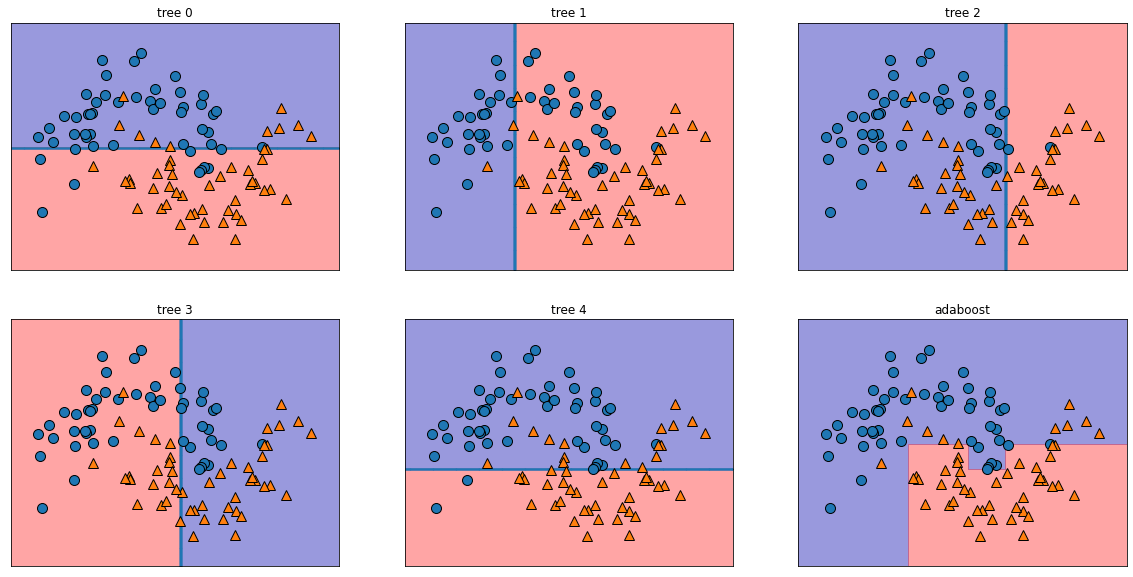

In [3]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(n_estimators=5, random_state=42)
ada.fit(xm_train, ym_train)

fig, axes = plt.subplots(2, 3, figsize=(20,10))
for i, (ax, tree) in enumerate(zip(axes.ravel(), ada.estimators_)):
    ax.set_title('tree {}'.format(i))
    mglearn.plots.plot_tree_partition(xm, ym, tree, ax=ax)
    
mglearn.plots.plot_2d_separator(ada, xm, fill=True, ax=axes[-1,-1], alpha=.4)
axes[-1,-1].set_title('adaboost')
mglearn.discrete_scatter(xm[:,0], xm[:,1], ym)
plt.show()

In [4]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(xc_train, yc_train)

print('train set score: {:.3f}'.format(ada.score(xc_train, yc_train)))
print('test set score: {:.3f}'.format(ada.score(xc_test, yc_test)))

train set score: 1.000
test set score: 0.986


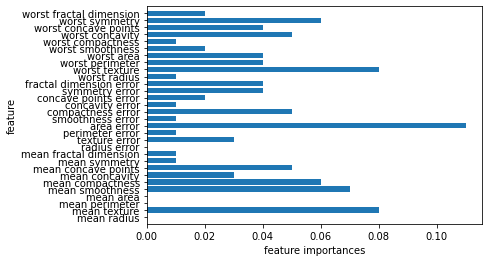

In [5]:
n_features = cancer.data.shape[1]
plt.barh(range(n_features), ada.feature_importances_, align='center')
plt.yticks(np.arange(n_features), cancer.feature_names)
plt.xlabel('feature importances')
plt.ylabel('feature')
plt.ylim(-1, n_features)
plt.show()

### 히스토그램 기반 부스팅

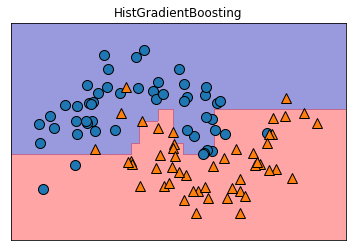

In [6]:
from sklearn.ensemble import HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(random_state=42)
hgb.fit(xm_train, ym_train)

mglearn.plots.plot_2d_separator(hgb, xm, fill=True, alpha=.4)
plt.title('HistGradientBoosting')
mglearn.discrete_scatter(xm[:,0], xm[:,1], ym)
plt.show()

In [7]:
hgb = HistGradientBoostingClassifier(random_state=42)
hgb.fit(xc_train, yc_train)

print('train set score: {:.3f}'.format(hgb.score(xc_train, yc_train)))
print('test set score: {:.3f}'.format(hgb.score(xc_test, yc_test)))

train set score: 1.000
test set score: 0.979


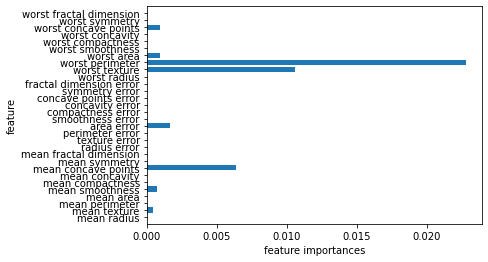

In [9]:
from sklearn.inspection import permutation_importance

result = permutation_importance(hgb, xc_train, yc_train, n_repeats=10, random_state=42, n_jobs=-1)
n_features = cancer.data.shape[1]
plt.barh(range(n_features), result.importances_mean, align='center')
plt.yticks(np.arange(n_features), cancer.feature_names)
plt.xlabel('feature importances')
plt.ylabel('feature')
plt.ylim(-1, n_features)
plt.show()

### 커널 서포트 벡터 머신

Text(0, 0.5, 'feature 1')

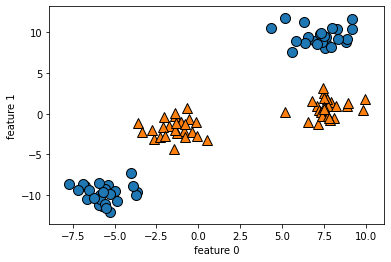

In [11]:
from sklearn.datasets import make_blobs
x, y = make_blobs(centers=4, random_state=8)
y = y % 2

mglearn.discrete_scatter(x[:,0], x[:,1], y)
plt.xlabel('feature 0')
plt.ylabel('feature 1')

Text(0, 0.5, 'feature 1')

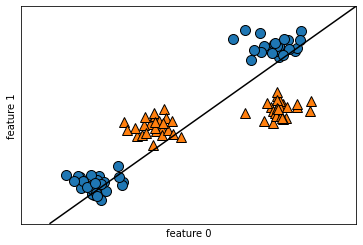

In [12]:
from sklearn.svm import LinearSVC
linear_svm = LinearSVC(max_iter=5000, tol=1e-3).fit(x, y)

mglearn.plots.plot_2d_separator(linear_svm, x)
mglearn.discrete_scatter(x[:,0], x[:,1], y)
plt.xlabel('feature 0')
plt.ylabel('feature 1')

Text(0.5, 0, 'feature1**2')

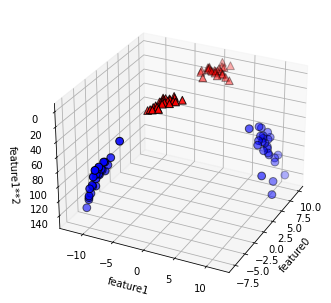

In [15]:
# 두 번째 특성을 제곱하여 추가합니다
x_new = np.hstack([x, x[:,1:] ** 2])
from mpl_toolkits.mplot3d import Axes3D, axes3d
figure = plt.figure()

# 3차원 그래프
ax = Axes3D(figure, elev=-152, azim=-26, auto_add_to_figure=False)
figure.add_axes(ax)

# y == 0인 포인트를 먼저 그리고 그 다음 y == 1인 포인트를 그립니다
mask = y == 0
ax.scatter(x_new[mask, 0], x_new[mask, 1], x_new[mask, 2], c='b', cmap=mglearn.cm2, s=60, edgecolor='k')
ax.scatter(x_new[~mask, 0], x_new[~mask, 1], x_new[~mask, 2], c='r', marker='^', cmap=mglearn.cm2, s=60, edgecolor='k')
ax.set_xlabel('feature0')
ax.set_ylabel('feature1')
ax.set_zlabel('feature1**2')

Text(0.5, 0, 'feature1**2')

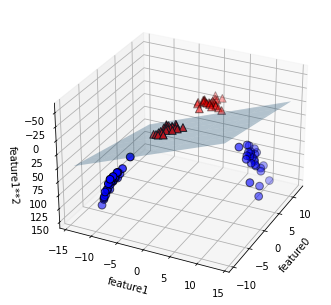

In [16]:
linear_svm_3d = LinearSVC(max_iter=5000).fit(x_new, y)
coef, intercept = linear_svm_3d.coef_.ravel(), linear_svm_3d.intercept_

# 선형 결정 경계 그리기
figure = plt.figure()
ax = Axes3D(figure, elev=-152, azim=-26, auto_add_to_figure=False)
figure.add_axes(ax)

xx = np.linspace(x_new[:,0].min() - 2, x_new[:,0].max() + 2, 50)
yy = np.linspace(x_new[:,1].min() - 2, x_new[:,1].max() + 2, 50)

xx, yy = np.meshgrid(xx, yy)
zz = (coef[0] * xx + coef[1] * yy + intercept) / -coef[2]
ax.plot_surface(xx, yy, zz, rstride=8, cstride=8, alpha=0.3)

ax.scatter(x_new[mask, 0], x_new[mask, 1], x_new[mask, 2], c='b', cmap=mglearn.cm2, s=60, edgecolor='k')
ax.scatter(x_new[~mask, 0], x_new[~mask, 1], x_new[~mask, 2], c='r', marker='^', cmap=mglearn.cm2, s=60, edgecolor='k')
ax.set_xlabel('feature0')
ax.set_ylabel('feature1')
ax.set_zlabel('feature1**2')

Text(0, 0.5, 'feature 1')

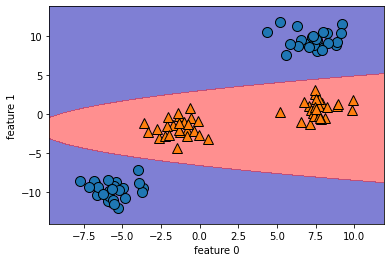

In [17]:
zz = yy ** 2
dec = linear_svm_3d.decision_function(np.c_[xx.ravel(), yy.ravel(), zz.ravel()])
plt.contourf(xx, yy, dec.reshape(xx.shape), levels=[dec.min(), 0, dec.max()], cmap=mglearn.cm2, alpha=0.5)
mglearn.discrete_scatter(x[:,0], x[:,1], y)
plt.xlabel('feature 0')
plt.ylabel('feature 1')

Text(0, 0.5, 'feature 1')

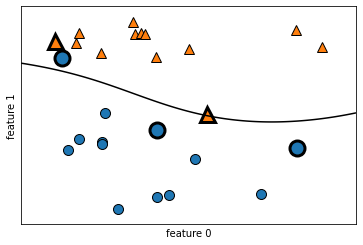

In [18]:
from sklearn.svm import SVC
x, y = mglearn.tools.make_handcrafted_dataset()
svm = SVC(kernel='rbf', C=10, gamma=0.1).fit(x, y)
mglearn.plots.plot_2d_separator(svm, x, eps=0.5)

# 데이터 포인트 그리기
mglearn.discrete_scatter(x[:,0], x[:,1], y)

# 서포트 벡터
sv = svm.support_vectors_

# dual_coef_ 의 부호에 의해 서포트 벡터의 클래스 레이블이 결정됩니다
sv_labels = svm.dual_coef_.ravel() > 0
mglearn.discrete_scatter(sv[:,0], sv[:,1], sv_labels, s=15, markeredgewidth=3)
plt.xlabel('feature 0')
plt.ylabel('feature 1')

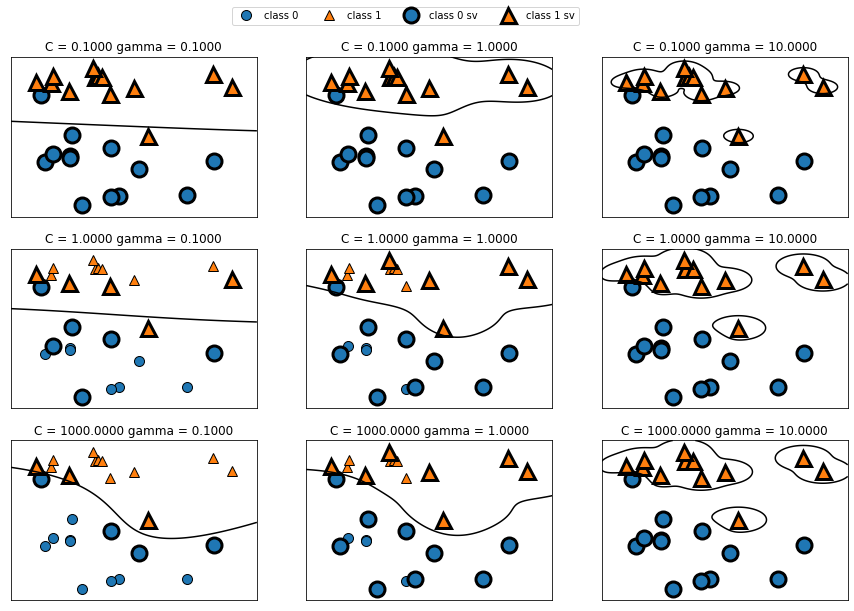

In [19]:
fig, axes = plt.subplots(3, 3, figsize=(15,10))

for ax, c in zip(axes, [-1,0,3]):
    for a, gamma in zip(ax, range(-1,2)):
        mglearn.plots.plot_svm(log_C=c, log_gamma=gamma, ax=a)

axes[0,0].legend(['class 0','class 1','class 0 sv','class 1 sv'], ncol=4, loc=(.9,1.2))

In [21]:
x_train, x_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)

svc = SVC()
svc.fit(x_train, y_train)

print('train set score: {:.3f}'.format(svc.score(x_train, y_train)))
print('test set score: {:.3f}'.format(svc.score(x_test, y_test)))

train set score: 0.904
test set score: 0.937


Text(0, 0.5, 'feature size')

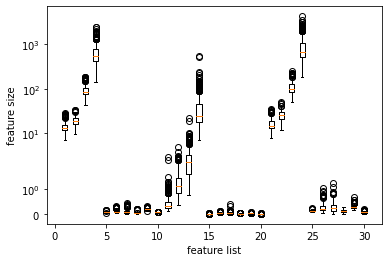

In [22]:
plt.boxplot(x_train, manage_ticks=False)
plt.yscale('symlog')
plt.xlabel('feature list')
plt.ylabel('feature size')

In [23]:
# 훈련 세트에서 특성별 최솟값 계산
min_on_training = x_train.min(axis=0)
# 훈련 세트에서 특성별 (최댓값 - 최솟값) 범위 계산
range_on_training = (x_train - min_on_training).max(axis=0)

# 훈련 데이터에서 최솟값을 빼고 범위로 나누면 각 특성에 대해 최솟값은 0 최댓값은 1입니다
x_train_scaled = (x_train - min_on_training) / range_on_training
print('min per feature\n', x_train_scaled.min(axis=0))
print('max per feature\n', x_train_scaled.max(axis=0))

min per feature
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
max per feature
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [24]:
# 테스트 세트에도 같은 작업을 적용하지만 훈련 세트에서 계산한 최솟값과 범위를 사용합니다
x_test_scaled = (x_test - min_on_training) / range_on_training

In [25]:
svc = SVC()
svc.fit(x_train_scaled, y_train)

print('train set score: {:.3f}'.format(svc.score(x_train_scaled, y_train)))
print('test set score: {:.3f}'.format(svc.score(x_test_scaled, y_test)))

train set score: 0.984
test set score: 0.972


In [26]:
svc = SVC(C=20)
svc.fit(x_train_scaled, y_train)
print('train set score: {:.3f}'.format(svc.score(x_train_scaled, y_train)))
print('test set score: {:.3f}'.format(svc.score(x_test_scaled, y_test)))

train set score: 0.988
test set score: 0.979


### 신경망

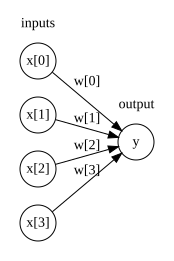

In [27]:
mglearn.plots.plot_logistic_regression_graph()

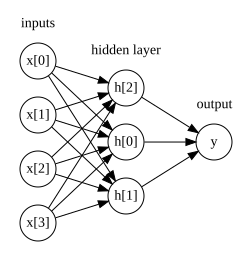

In [28]:
mglearn.plots.plot_single_hidden_layer_graph()

Text(0, 0.5, 'relu(x), tanh(x)')

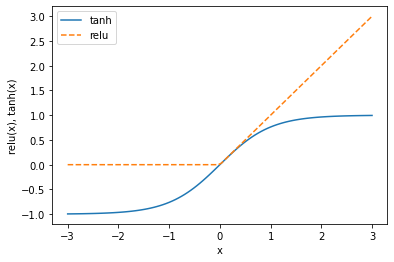

In [30]:
line = np.linspace(-3,3,100)
plt.plot(line, np.tanh(line), label='tanh')
plt.plot(line, np.maximum(line, 0), linestyle='--', label='relu')
plt.legend(loc='best')
plt.xlabel('x')
plt.ylabel('relu(x), tanh(x)')

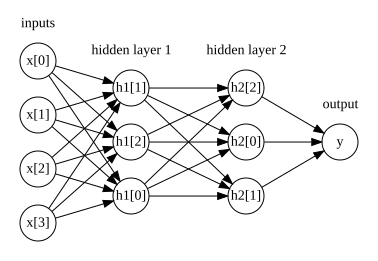

In [31]:
mglearn.plots.plot_two_hidden_layer_graph()

Text(0, 0.5, 'feature 1')

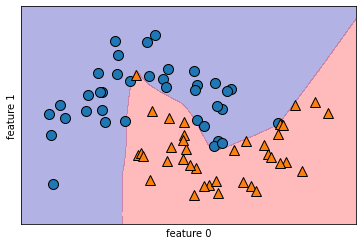

In [32]:
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons

x, y = make_moons(n_samples=100, noise=0.25, random_state=3)

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, random_state=42)

mlp = MLPClassifier(solver='lbfgs', random_state=0).fit(x_train, y_train)
mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3)
mglearn.discrete_scatter(x_train[:,0], x_train[:,1], y_train)
plt.xlabel('feature 0')
plt.ylabel('feature 1')

Text(0, 0.5, 'feature 1')

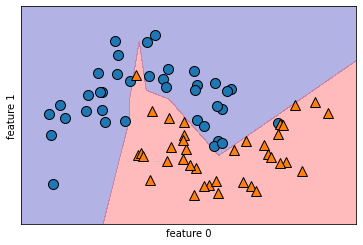

In [33]:
mlp = MLPClassifier(solver='lbfgs', random_state=0, hidden_layer_sizes=[10], max_iter=1000)
mlp.fit(x_train, y_train)
mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3)
mglearn.discrete_scatter(x_train[:,0], x_train[:,1], y_train)
plt.xlabel('feature 0')
plt.ylabel('feature 1')

Text(0, 0.5, 'feature 1')

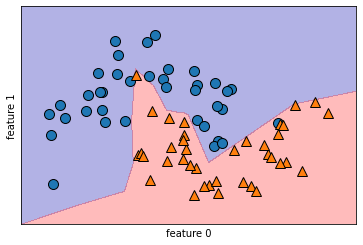

In [34]:
# 10개의 유닛으로 된 두 개의 은닉층
mlp = MLPClassifier(solver='lbfgs', random_state=0, hidden_layer_sizes=[10,10], max_iter=1000)
mlp.fit(x_train, y_train)
mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3)
mglearn.discrete_scatter(x_train[:,0], x_train[:,1], y_train)
plt.xlabel('feature 0')
plt.ylabel('feature 1')

Text(0, 0.5, 'feature 1')

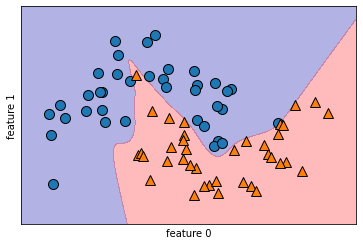

In [35]:
# tanh 활성화 함수가 적용된 10개의 유닛으로 된 두 개의 은닉층
mlp = MLPClassifier(solver='lbfgs', activation='tanh', random_state=0, hidden_layer_sizes=[10,10], max_iter=1000)
mlp.fit(x_train, y_train)
mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3)
mglearn.discrete_scatter(x_train[:,0], x_train[:,1], y_train)
plt.xlabel('feature 0')
plt.ylabel('feature 1')

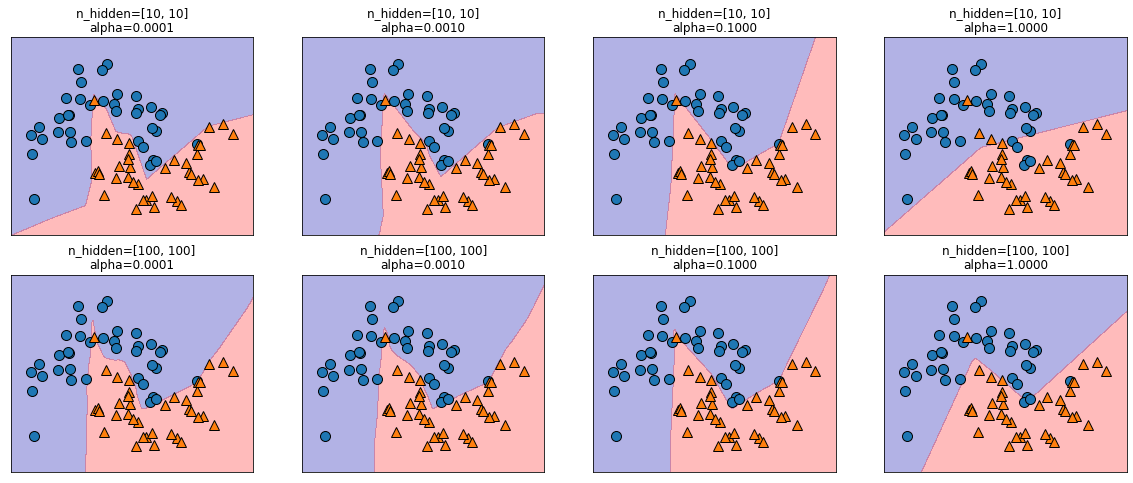

In [36]:
fig, axes = plt.subplots(2, 4, figsize=(20,8))
for axx, n_hidden_nodes in zip(axes, [10,100]):
    for ax, alpha in zip(axx, [0.0001,0.001,0.1,1]):
        mlp = MLPClassifier(solver='lbfgs', random_state=0, max_iter=1000, 
                            hidden_layer_sizes=[n_hidden_nodes, n_hidden_nodes], alpha=alpha)
        mlp.fit(x_train, y_train)
        mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3, ax=ax)
        mglearn.discrete_scatter(x_train[:,0], x_train[:,1], y_train, ax=ax)
        ax.set_title('n_hidden=[{}, {}]\nalpha={:.4f}'.format(n_hidden_nodes, n_hidden_nodes, alpha))

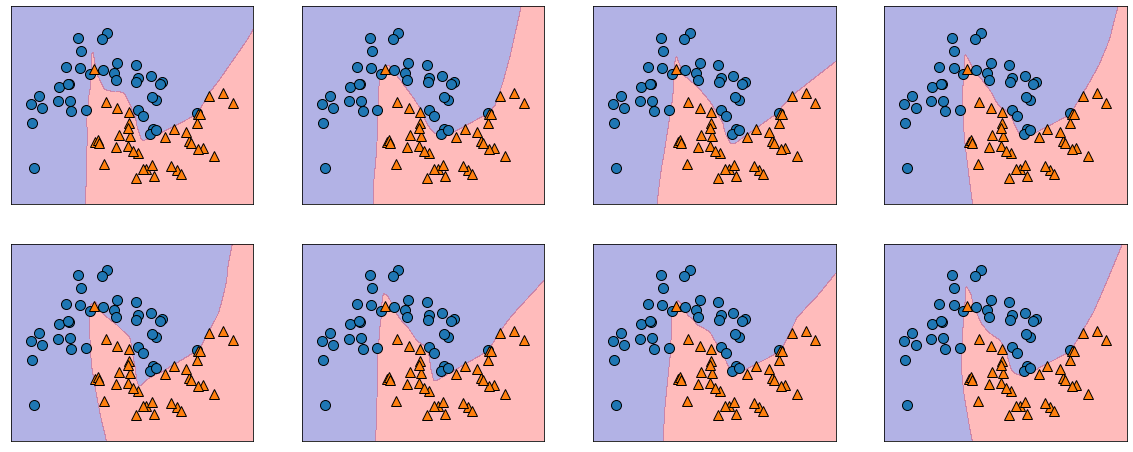

In [37]:
fig, axes = plt.subplots(2, 4, figsize=(20,8))
for i, ax in enumerate(axes.ravel()):
    mlp = MLPClassifier(solver='lbfgs', random_state=i, hidden_layer_sizes=[100,100])
    mlp.fit(x_train, y_train)
    mglearn.plots.plot_2d_separator(mlp, x_train, fill=True, alpha=.3, ax=ax)
    mglearn.discrete_scatter(x_train[:,0], x_train[:,1], y_train, ax=ax)

In [38]:
print('cancer data / max per feature:\n', cancer.data.max(axis=0))

cancer data / max per feature:
 [2.811e+01 3.928e+01 1.885e+02 2.501e+03 1.634e-01 3.454e-01 4.268e-01
 2.012e-01 3.040e-01 9.744e-02 2.873e+00 4.885e+00 2.198e+01 5.422e+02
 3.113e-02 1.354e-01 3.960e-01 5.279e-02 7.895e-02 2.984e-02 3.604e+01
 4.954e+01 2.512e+02 4.254e+03 2.226e-01 1.058e+00 1.252e+00 2.910e-01
 6.638e-01 2.075e-01]


In [39]:
x_train, x_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)

mlp = MLPClassifier(random_state=42)
mlp.fit(x_train, y_train)

print('train set score: {:.2f}'.format(mlp.score(x_train, y_train)))
print('test set score: {:.2f}'.format(mlp.score(x_test, y_test)))

train set score: 0.94
test set score: 0.92


In [40]:
# 훈련 세트 각 특성의 평균을 계산합니다
mean_on_train = x_train.mean(axis=0)
# 훈련 세트 각 특성의 표준 편차를 계산합니다
std_on_train = x_train.std(axis=0)

# 데이터에서 평균을 빼고 표준 편차로 나누면 평균 0, 표준 편차 1인 데이터로 변환됩니다
x_train_scaled = (x_train - mean_on_train) / std_on_train
# (훈련 데이터의 평균과 표준 편차를 이용해) 같은 변환을 테스트 세트에도 합니다
x_test_scaled = (x_test - mean_on_train) / std_on_train

mlp = MLPClassifier(random_state=0)
mlp.fit(x_train_scaled, y_train)

print('train set score: {:.3f}'.format(mlp.score(x_train_scaled, y_train)))
print('test set score: {:.3f}'.format(mlp.score(x_test_scaled, y_test)))

train set score: 0.991
test set score: 0.965


In [41]:
mlp = MLPClassifier(max_iter=1000, random_state=0)
mlp.fit(x_train_scaled, y_train)

print('train set score: {:.3f}'.format(mlp.score(x_train_scaled, y_train)))
print('test set score: {:.3f}'.format(mlp.score(x_test_scaled, y_test)))

train set score: 1.000
test set score: 0.972


In [42]:
mlp = MLPClassifier(max_iter=1000, alpha=1, random_state=0)
mlp.fit(x_train_scaled, y_train)

print('train set score: {:.3f}'.format(mlp.score(x_train_scaled, y_train)))
print('test set score: {:.3f}'.format(mlp.score(x_test_scaled, y_test)))

train set score: 0.988
test set score: 0.972


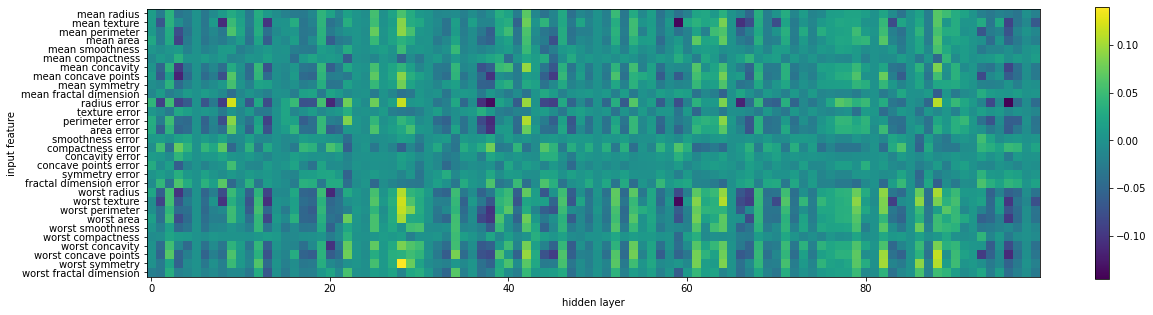

In [43]:
plt.figure(figsize=(20,5))
plt.imshow(mlp.coefs_[0], interpolation='none', cmap='viridis')
plt.yticks(range(30), cancer.feature_names)
plt.xlabel('hidden layer')
plt.ylabel('input feature')
plt.colorbar()

### 분류 예측의 불확실성 추정

In [44]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.datasets import make_circles
x, y = make_circles(noise=0.25, factor=0.5, random_state=1)

# 예제를 위해 클래스의 이름을 'blue'와 'red'로 바꿉니다
y_named = np.array(['blue','red'])[y]

# 여러 개의 배열을 한꺼번에 train_test_split에 넣을 수 있습니다
# 훈련 세트와 테스트 세트로 나뉘는 방식은 모두 같습니다
x_train, x_test, y_train_named, y_test_named, y_train, y_test = train_test_split(x, y_named, y, random_state=0)

# 그래디언트 부스팅 모델을 만듭니다
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(x_train, y_train_named)

GradientBoostingClassifier(random_state=0)

In [45]:
print('x_test.shape:', x_test.shape)
print('decision_function shape:', gbrt.decision_function(x_test).shape)

x_test.shape: (25, 2)
decision_function shape: (25,)


In [46]:
print('decision function:\n', gbrt.decision_function(x_test)[:6])

decision function:
 [ 4.13592603 -1.70169917 -3.95106099 -3.62609552  4.28986642  3.66166081]


In [47]:
print('compare result(decision function) with critical:\n', gbrt.decision_function(x_test) > 0)
print('predict:\n', gbrt.predict(x_test))

compare result(decision function) with critical:
 [ True False False False  True  True False  True  True  True False  True
  True False  True False False False  True  True  True  True  True False
 False]
predict:
 ['red' 'blue' 'blue' 'blue' 'red' 'red' 'blue' 'red' 'red' 'red' 'blue'
 'red' 'red' 'blue' 'red' 'blue' 'blue' 'blue' 'red' 'red' 'red' 'red'
 'red' 'blue' 'blue']


In [49]:
# 불린 값을 0과 1로 변환합니다
greater_zero = (gbrt.decision_function(x_test) > 0).astype(int)
# classes_에 인덱스로 사용합니다
pred = gbrt.classes_[greater_zero]
# pred와 gbrt.predict의 결과를 비교합니다
print('pred = predict result:', np.all(pred == gbrt.predict(x_test)))

pred = predict result: True


In [50]:
decision_function = gbrt.decision_function(x_test)
print('decision function min: {:.2f} max: {:.2f}'.format(np.min(decision_function), np.max(decision_function)))

decision function min: -7.69 max: 4.29


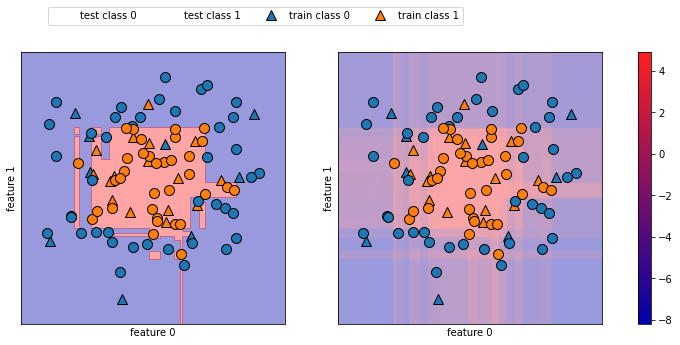

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

mglearn.tools.plot_2d_separator(gbrt, x, ax=axes[0], alpha=.4, fill=True, cm=mglearn.cm2)
scores_image = mglearn.tools.plot_2d_scores(gbrt, x, ax=axes[1], alpha=.4, cm=mglearn.ReBl)

for ax in axes:
    # 훈련 포인트와 테스트 포인트를 그리기
    mglearn.discrete_scatter(x_test[:,0], x_test[:,1], y_test, markers='^', ax=ax)
    mglearn.discrete_scatter(x_train[:,0], x_train[:,1], y_train, markers='o', ax=ax)
    ax.set_xlabel('feature 0')
    ax.set_ylabel('feature 1')

cbar = plt.colorbar(scores_image, ax=axes.tolist())
cbar.set_alpha(1)
cbar.draw_all()
axes[0].legend(['test class 0','test class 1','train class 0','train class 1'], ncol=4, loc=(.1,1.1))

In [52]:
print('predict shape:', gbrt.predict_proba(x_test).shape)

predict shape: (25, 2)


In [53]:
# predict_proba 결과 중 앞부분 일부를 확인합니다
print('predict:\n', gbrt.predict_proba(x_test[:6]))

predict:
 [[0.01573626 0.98426374]
 [0.84575653 0.15424347]
 [0.98112869 0.01887131]
 [0.97407033 0.02592967]
 [0.01352142 0.98647858]
 [0.02504637 0.97495363]]


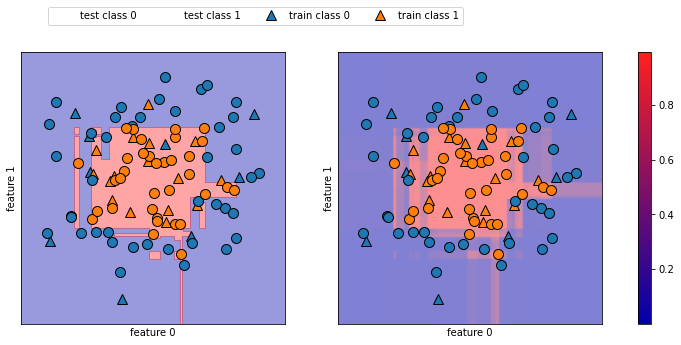

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

mglearn.tools.plot_2d_separator(gbrt, x, ax=axes[0], alpha=.4, fill=True, cm=mglearn.cm2)
scores_image = mglearn.tools.plot_2d_scores(gbrt, x, ax=axes[1], alpha=.5, cm=mglearn.ReBl, function='predict_proba')
for ax in axes:
    mglearn.discrete_scatter(x_test[:,0], x_test[:,1], y_test, markers='^', ax=ax)
    mglearn.discrete_scatter(x_train[:,0], x_train[:,1], y_train, markers='o', ax=ax)
    ax.set_xlabel('feature 0')
    ax.set_ylabel('feature 1')

# colorbar를 감추지 않습니다
cbar = plt.colorbar(scores_image,ax=axes.tolist())
cbar.set_alpha(1)
cbar.draw_all()
axes[0].legend(['test class 0','test class 1','train class 0','train class 1'], ncol=4, loc=(.1,1.1))

In [56]:
from sklearn.datasets import load_iris

iris = load_iris()
x_train, x_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=42)

gbrt = GradientBoostingClassifier(learning_rate=0.01, random_state=0)
gbrt.fit(x_train, y_train)

GradientBoostingClassifier(learning_rate=0.01, random_state=0)

In [57]:
print('decision function shape:', gbrt.decision_function(x_test).shape)
print('decision function result:\n', gbrt.decision_function(x_test)[:6, :])

decision function shape: (38, 3)
decision function result:
 [[-1.995715    0.04758267 -1.92720695]
 [ 0.06146394 -1.90755736 -1.92793758]
 [-1.99058203 -1.87637861  0.09686725]
 [-1.995715    0.04758267 -1.92720695]
 [-1.99730159 -0.13469108 -1.20341483]
 [ 0.06146394 -1.90755736 -1.92793758]]


In [58]:
print('max index:\n', np.argmax(gbrt.decision_function(x_test), axis=1))
print('predict:\n', gbrt.predict(x_test))

max index:
 [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]
predict:
 [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]


In [59]:
print('predict_proba:\n', gbrt.predict_proba(x_test)[:6])
print('sum:', gbrt.predict_proba(x_test)[:6].sum(axis=1))

predict_proba:
 [[0.10217718 0.78840034 0.10942248]
 [0.78347147 0.10936745 0.10716108]
 [0.09818072 0.11005864 0.79176065]
 [0.10217718 0.78840034 0.10942248]
 [0.10360005 0.66723901 0.22916094]
 [0.78347147 0.10936745 0.10716108]]
sum: [1. 1. 1. 1. 1. 1.]


In [60]:
print('max index:\n', np.argmax(gbrt.predict_proba(x_test), axis=1))
print('predict:\n', gbrt.predict(x_test))

max index:
 [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]
predict:
 [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0]


In [61]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000)

named_target = iris.target_names[y_train]
logreg.fit(x_train, named_target)
print('class list:', logreg.classes_)
print('predict:', logreg.predict(x_test)[:10])
argmax_dec_func = np.argmax(logreg.decision_function(x_test), axis=1)
print('max index:', argmax_dec_func[:10])
print('index connect to classes_:', logreg.classes_[argmax_dec_func][:10])

class list: ['setosa' 'versicolor' 'virginica']
predict: ['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor']
max index: [1 0 2 1 1 0 1 2 1 1]
index connect to classes_: ['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor']
